# ANADI – Trabalho Prático 2
## 4.1 Análise Exploratória de Dados (EDA)
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Analisar o impacto da eficiência energética na iluminação pública sobre a reserva de potência dos Postos de Transformação de Distribuição (PTD) e avaliar a viabilidade de instalação de carregadores de veículos elétricos.

---
## 1. Carregamento do Dataset

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print('Dimensão do dataset:', df.shape)
print(f'Registos: {df.shape[0]:,} | Variáveis: {df.shape[1]}')

Dimensão do dataset: (72027, 32)
Registos: 72,027 | Variáveis: 32


In [82]:
# Primeiros registos
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,Pot_Geracao_kW,N_Clientes_Produtores,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,N_Luminarias,N_Lampadas,N_PTDs_Concelho,PVE_PTD,D_PTD,IP_per_PTD,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,64.08,3.522977,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,35.10,3.522977,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,-13.20,3.522977,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,NaN,20,1307.0245,991.25,0.758402,0.239777,21315,21286,371,13.2,173.10,3.522977,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [83]:
# Informação geral: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [84]:
# Sumário estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568


---
## 2. Exploração Visual dos Dados

### 2.1 Valores Omissos

                         Valores Omissos  Percentagem (%)
Pot_Geracao_kW                     70191            97.45
Geracao_per_Cliente                70191            97.45
PContratada_per_Cliente            21180            29.41
Pot_Contratada_kVA                 21180            29.41
D_PTD_LED                           3064             4.25
D_PTD                               3064             4.25
Util_Decimal                        3064             4.25
PFolga_PTD                          3064             4.25


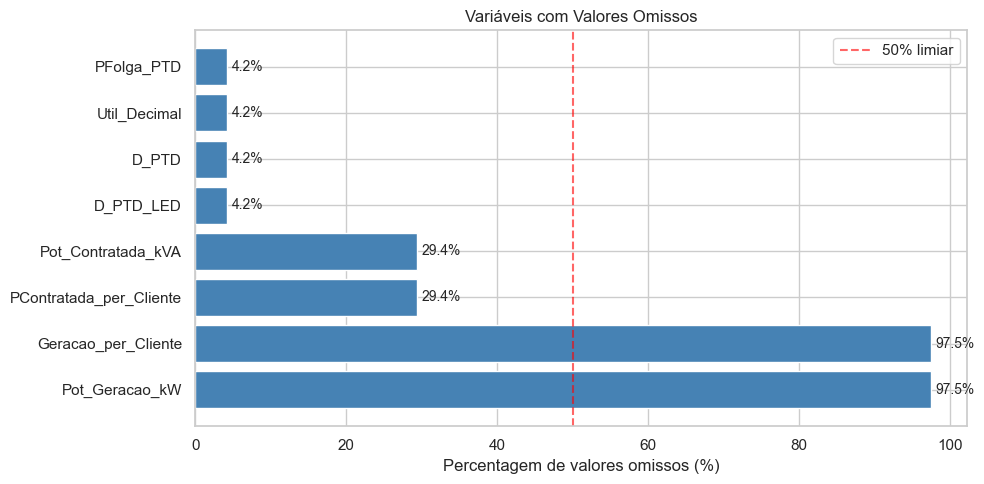

In [85]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Omissos': missing, 'Percentagem (%)': missing_pct})
missing_df = missing_df[missing_df['Valores Omissos'] > 0].sort_values('Percentagem (%)', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentagem (%)'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Percentagem de valores omissos (%)')
ax.set_title('Variáveis com Valores Omissos')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% limiar')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Categórica: Tipo Construtivo

C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\1570791492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')


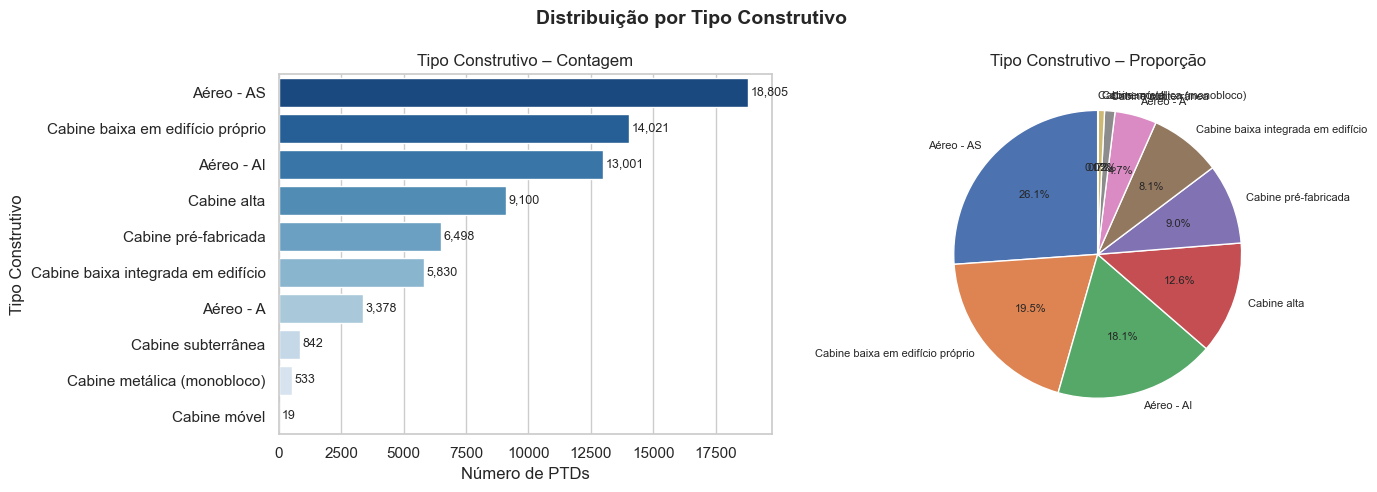

In [86]:
tipo_counts = df['Tipo Construtivo'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_xlabel('Número de PTDs')
axes[0].set_title('Tipo Construtivo – Contagem')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Gráfico circular
axes[1].pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Tipo Construtivo – Proporção')

plt.suptitle('Distribuição por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Distribuição do Nível de Utilização dos PTDs

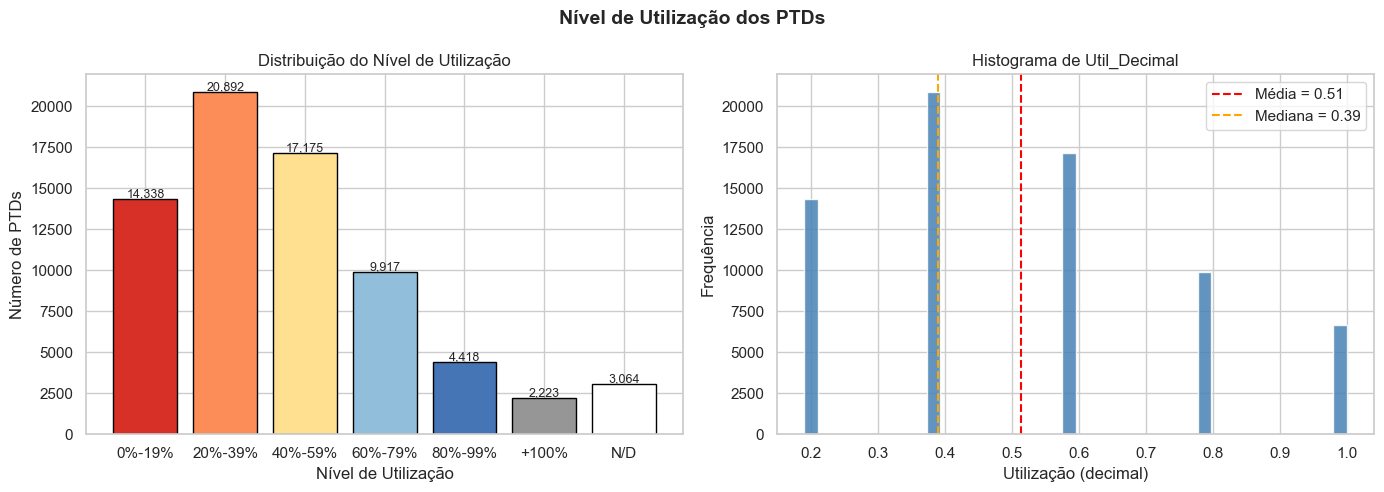

PTDs com utilização acima de 80%: 6,641 (9.6%)
PTDs com utilização acima de 100%: 2,223 (3.2%)


In [87]:
util_col = [c for c in df.columns if 'Utiliza' in c][0]
util_counts = df[util_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por categoria
cores = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#969696', '#ffffff']
cats_order = ['0%-19%', '20%-39%', '40%-59%', '60%-79%', '80%-99%', '+100%', 'N/D']
ordered = [util_counts.get(c, 0) for c in cats_order]
axes[0].bar(cats_order, ordered, color=cores[:len(cats_order)], edgecolor='black')
axes[0].set_xlabel('Nível de Utilização')
axes[0].set_ylabel('Número de PTDs')
axes[0].set_title('Distribuição do Nível de Utilização')
for i, v in enumerate(ordered):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Histograma de Util_Decimal (excluindo N/D)
util_dec = df['Util_Decimal'].dropna()
axes[1].hist(util_dec, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(util_dec.mean(), color='red', linestyle='--', label=f'Média = {util_dec.mean():.2f}')
axes[1].axvline(util_dec.median(), color='orange', linestyle='--', label=f'Mediana = {util_dec.median():.2f}')
axes[1].set_xlabel('Utilização (decimal)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Util_Decimal')
axes[1].legend()

plt.suptitle('Nível de Utilização dos PTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PTDs com utilização acima de 80%: {(util_dec >= 0.8).sum():,} ({(util_dec >= 0.8).mean()*100:.1f}%)')
print(f'PTDs com utilização acima de 100%: {(util_dec >= 1.0).sum():,} ({(util_dec >= 1.0).mean()*100:.1f}%)')

### 2.4 Distribuição das Variáveis Numéricas Principais

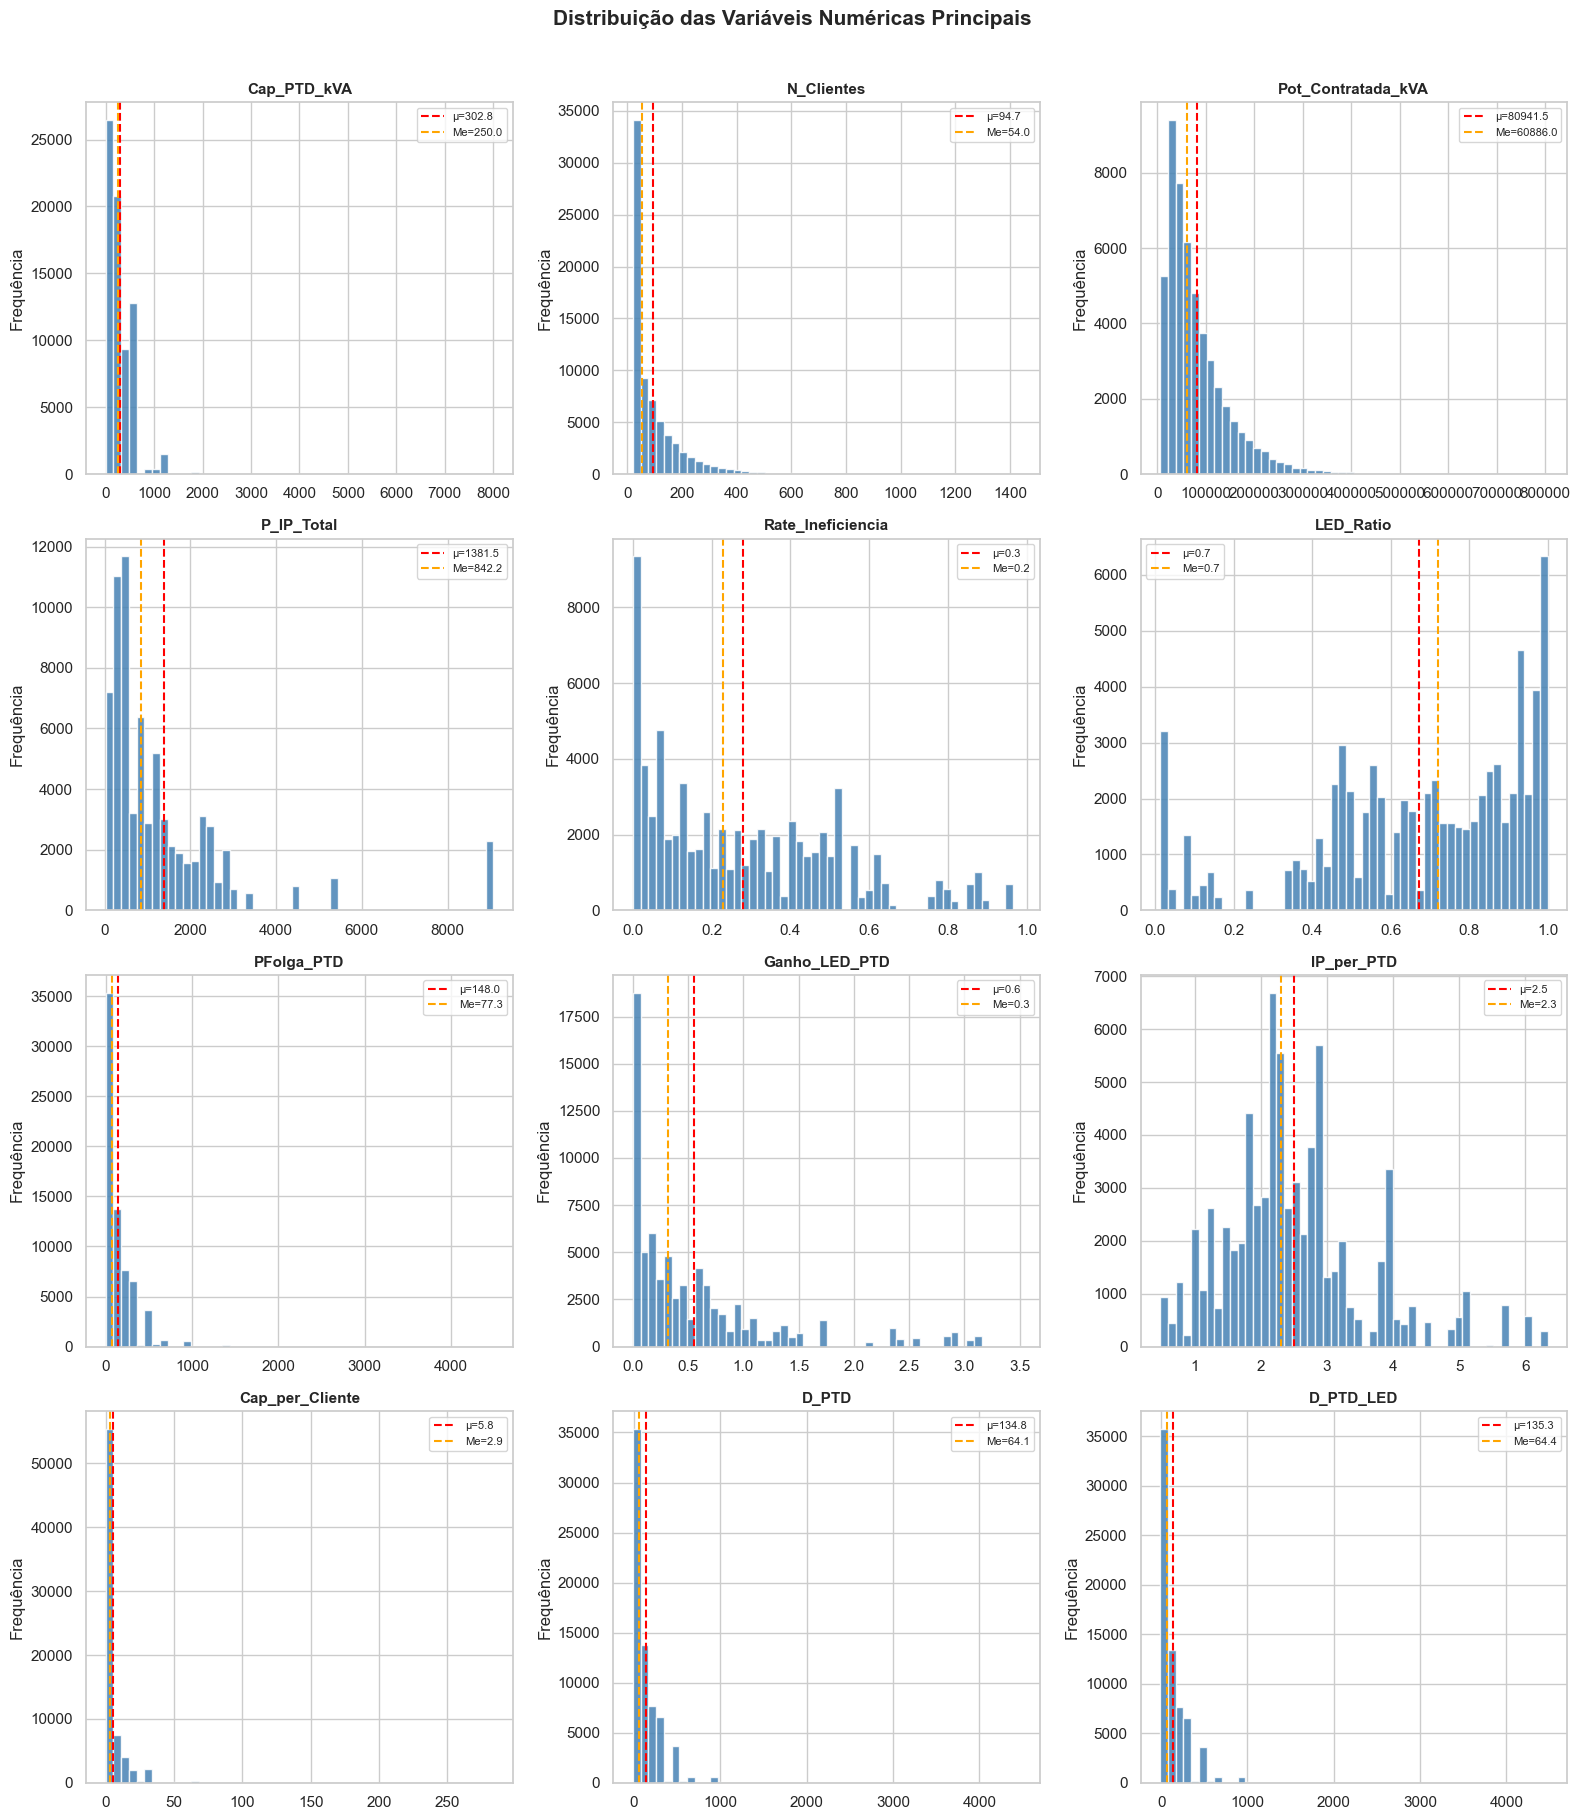

In [88]:
vars_principais = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'PFolga_PTD', 'Ganho_LED_PTD', 'IP_per_PTD',
    'Cap_per_Cliente', 'D_PTD', 'D_PTD_LED'
]

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Me={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Boxplots por Tipo Construtivo

C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rafae\AppData\Local\Temp\ipykernel_25112\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

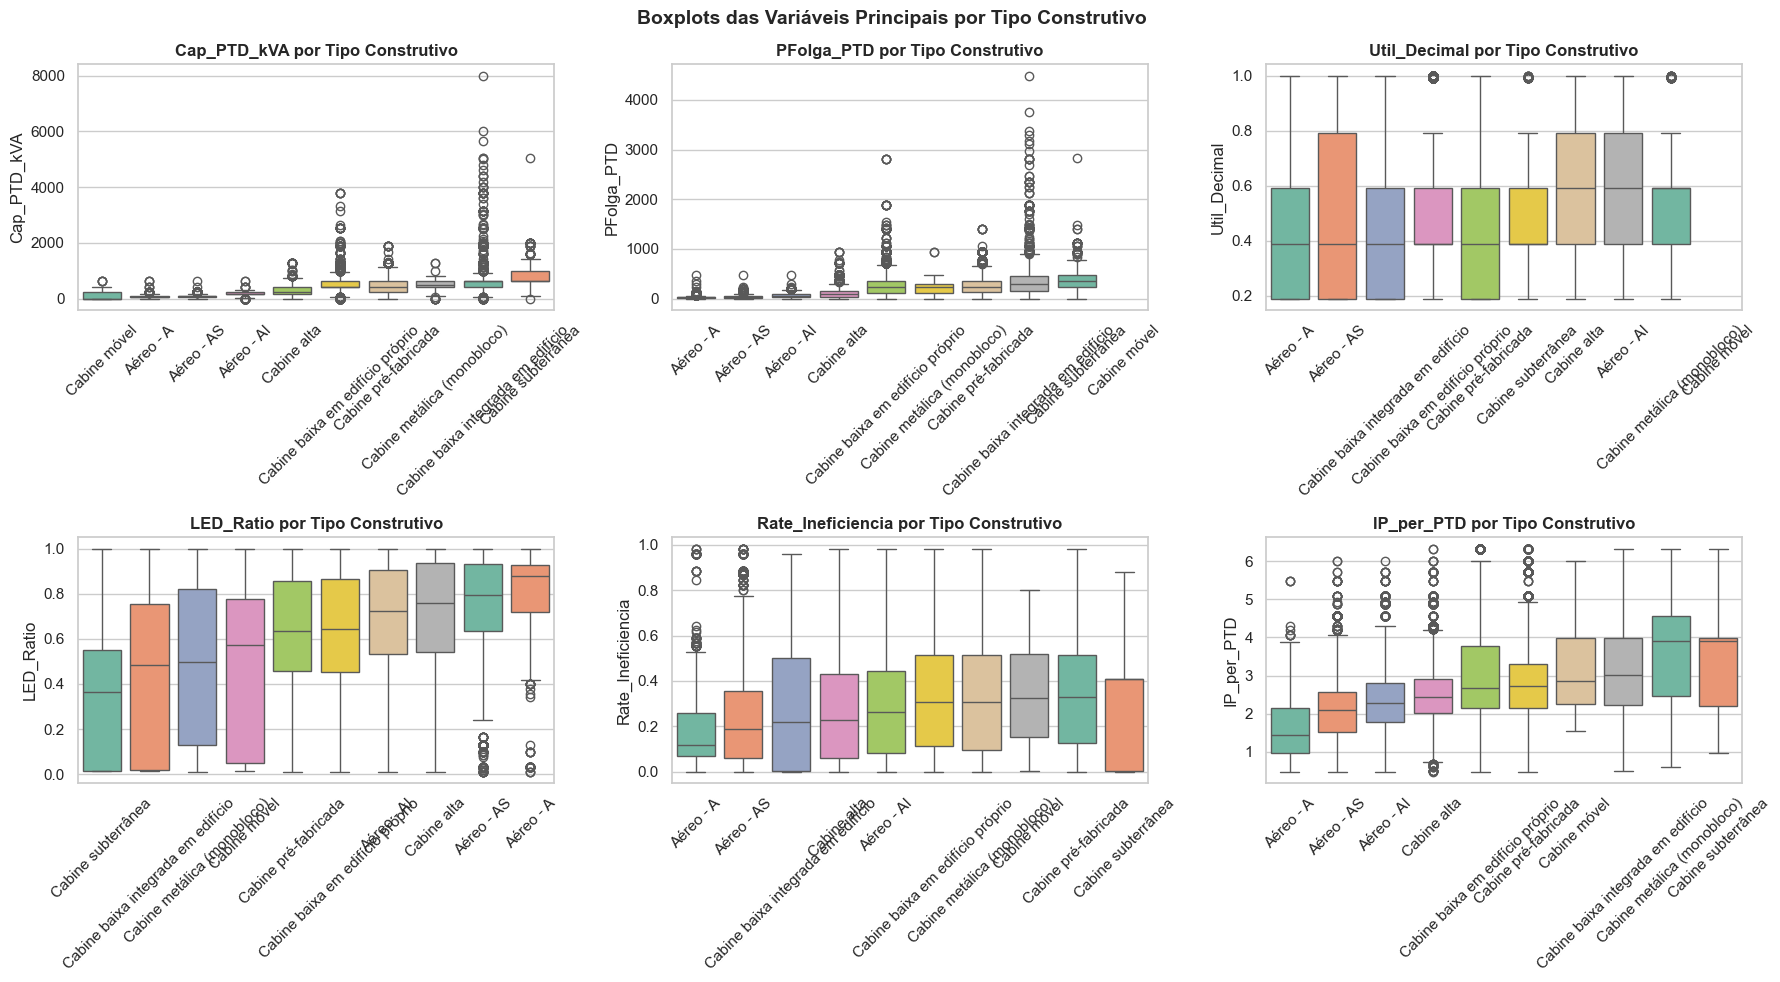

In [89]:
vars_boxplot = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio', 'Rate_Ineficiencia', 'IP_per_PTD']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    sns.boxplot(
        data=df, x='Tipo Construtivo', y=col,
        ax=axes[i], palette='Set2',
        order=df.groupby('Tipo Construtivo')[col].median().sort_values().index
    )
    axes[i].set_title(f'{col} por Tipo Construtivo', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots das Variáveis Principais por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Matriz de Correlação

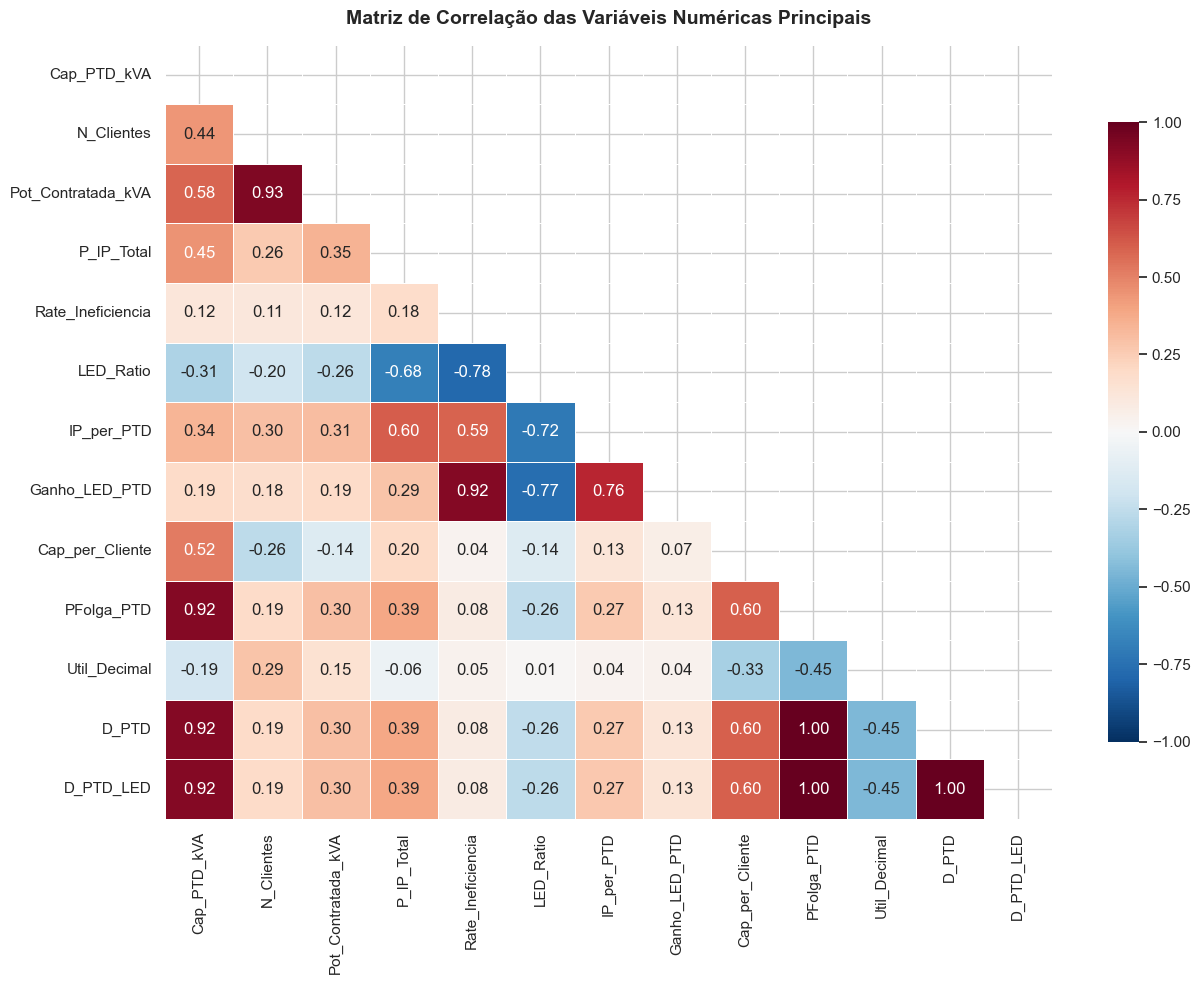

In [90]:
vars_corr = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente',
    'PFolga_PTD', 'Util_Decimal', 'D_PTD', 'D_PTD_LED'
]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação das Variáveis Numéricas Principais', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.7 Relações-Chave entre Variáveis

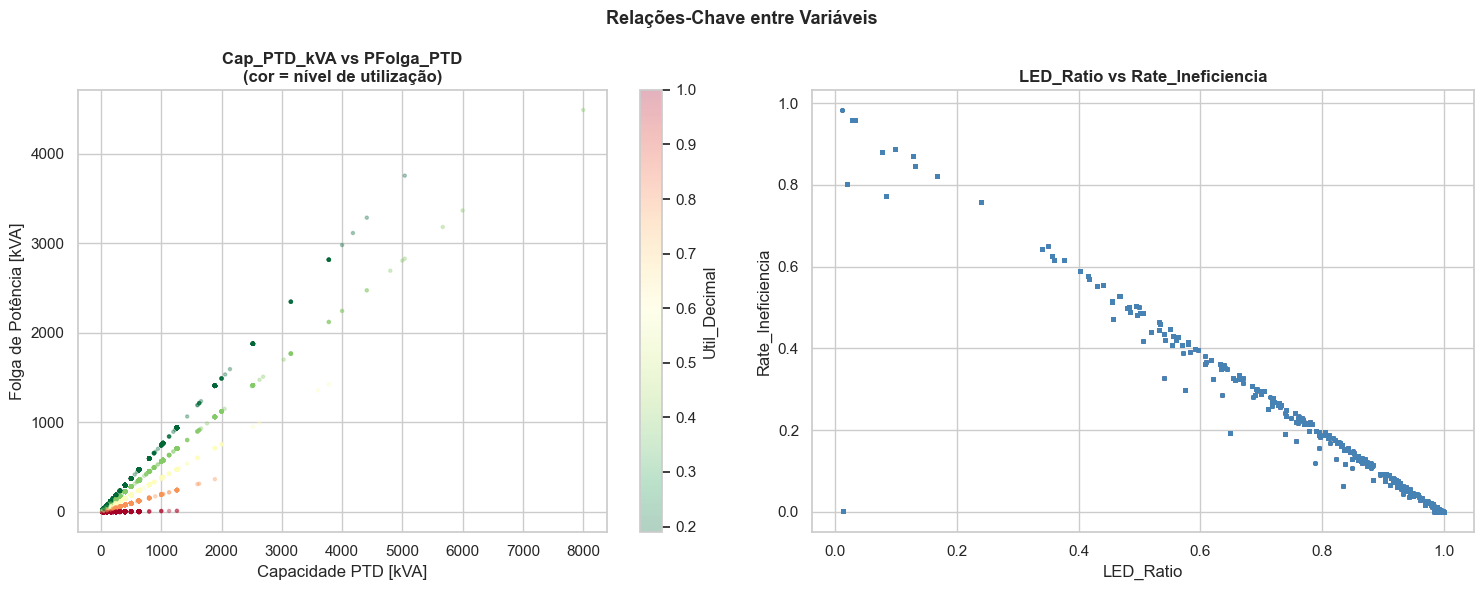

In [91]:
# Folga de Potência vs Capacidade do PTD — colorido por Tipo Construtivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_data = df[['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio',
                    'Rate_Ineficiencia', 'Tipo Construtivo']].dropna()

# Scatter: Cap_PTD_kVA vs PFolga_PTD
sc1 = axes[0].scatter(
    scatter_data['Cap_PTD_kVA'], scatter_data['PFolga_PTD'],
    c=scatter_data['Util_Decimal'], cmap='RdYlGn_r',
    alpha=0.3, s=5
)
plt.colorbar(sc1, ax=axes[0], label='Util_Decimal')
axes[0].set_xlabel('Capacidade PTD [kVA]')
axes[0].set_ylabel('Folga de Potência [kVA]')
axes[0].set_title('Cap_PTD_kVA vs PFolga_PTD\n(cor = nível de utilização)', fontweight='bold')

# Scatter: LED_Ratio vs Rate_Ineficiencia
sc2 = axes[1].scatter(
    scatter_data['LED_Ratio'], scatter_data['Rate_Ineficiencia'],
    alpha=0.2, s=5, color='steelblue'
)
axes[1].set_xlabel('LED_Ratio')
axes[1].set_ylabel('Rate_Ineficiencia')
axes[1].set_title('LED_Ratio vs Rate_Ineficiencia', fontweight='bold')

plt.suptitle('Relações-Chave entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

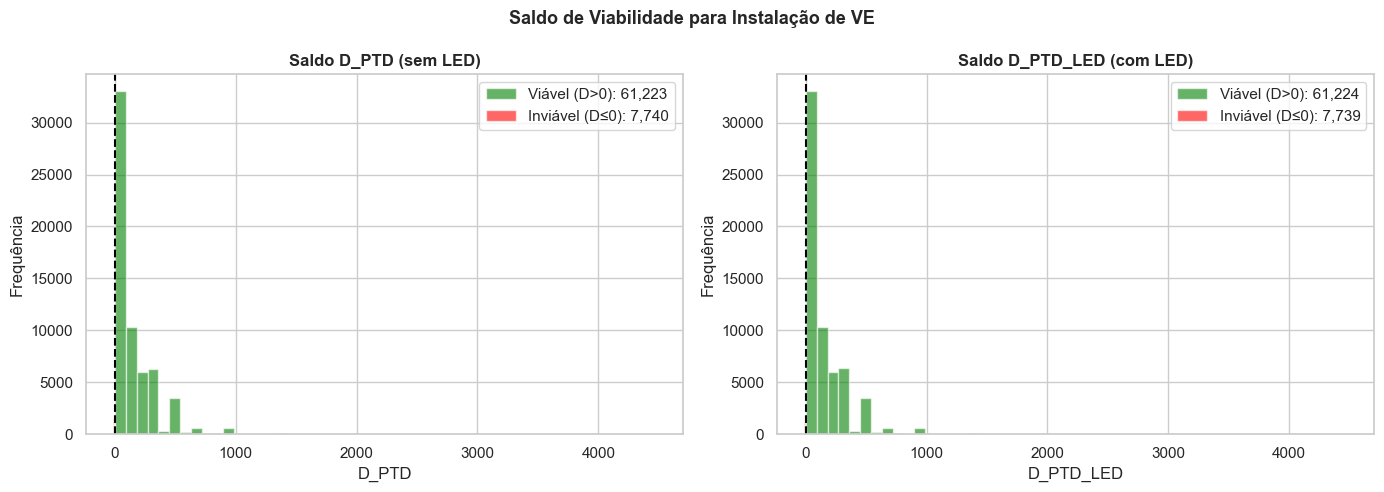

PTDs viáveis SEM LED:  61,223 / 68,963 (88.8%)
PTDs viáveis COM LED:  61,224 / 68,963 (88.8%)


In [92]:
# Distribuição de D_PTD e D_PTD_LED — Viabilidade de VE
d_data = df[['D_PTD', 'D_PTD_LED']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['D_PTD', 'D_PTD_LED'],
                           ['Saldo D_PTD (sem LED)', 'Saldo D_PTD_LED (com LED)']):
    data = d_data[col]
    pos = (data > 0).sum()
    neg = (data <= 0).sum()
    ax.hist(data[data > 0], bins=50, color='green', alpha=0.6, label=f'Viável (D>0): {pos:,}')
    ax.hist(data[data <= 0], bins=30, color='red', alpha=0.6, label=f'Inviável (D≤0): {neg:,}')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Saldo de Viabilidade para Instalação de VE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(d_data)
print(f'PTDs viáveis SEM LED:  {(d_data["D_PTD"] > 0).sum():,} / {total:,} ({(d_data["D_PTD"] > 0).mean()*100:.1f}%)')
print(f'PTDs viáveis COM LED:  {(d_data["D_PTD_LED"] > 0).sum():,} / {total:,} ({(d_data["D_PTD_LED"] > 0).mean()*100:.1f}%)')

---
## 3. Pré-processamento dos Dados
### 3.1 Tratamento de Valores Omissos

In [93]:
df_clean = df.copy()

# Pot_Geracao_kW e Geracao_per_Cliente: ~97% de valores omissos → remover colunas
cols_drop_missing = ['Pot_Geracao_kW', 'Geracao_per_Cliente']
df_clean.drop(columns=cols_drop_missing, inplace=True)
print(f'Colunas removidas por excesso de valores omissos (>95%): {cols_drop_missing}')

# Nível de Utilização com valor "N/D" corresponde às mesmas linhas com PFolga_PTD = NaN
# Remover registos sem PFolga_PTD (não é possível calcular métricas principais)
n_antes = len(df_clean)
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)
print(f'Registos removidos (PFolga_PTD/Util indefinido): {n_antes - len(df_clean):,}')
print(f'Registos restantes: {len(df_clean):,}')

# Pot_Contratada_kVA: ~29% de valores omissos → imputar com mediana por Tipo Construtivo
df_clean['Pot_Contratada_kVA'] = df_clean.groupby('Tipo Construtivo')['Pot_Contratada_kVA'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['PContratada_per_Cliente'] = df_clean.groupby('Tipo Construtivo')['PContratada_per_Cliente'].transform(
    lambda x: x.fillna(x.median())
)
print(f'\nValores omissos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Colunas removidas por excesso de valores omissos (>95%): ['Pot_Geracao_kW', 'Geracao_per_Cliente']
Registos removidos (PFolga_PTD/Util indefinido): 3,064
Registos restantes: 68,963

Valores omissos restantes:
Series([], dtype: int64)


### 3.2 Transformação de Variáveis Categóricas

In [94]:
# Tipo Construtivo → Label Encoding (ordenado por mediana de Cap_PTD_kVA)
le = LabelEncoder()
df_clean['Tipo_Construtivo_Enc'] = le.fit_transform(df_clean['Tipo Construtivo'])

mapeamento = pd.DataFrame({'Categoria': le.classes_,
                            'Código': range(len(le.classes_))})
print('Mapeamento Label Encoding – Tipo Construtivo:')
print(mapeamento.to_string(index=False))

# Nível de Utilização [%] → já existe Util_Decimal (variável numérica equivalente)
# Criar também variável binária de saturação (>=80%)
df_clean['PTD_Saturado'] = (df_clean['Util_Decimal'] >= 0.8).astype(int)
print(f'\nPTDs saturados (≥80%): {df_clean["PTD_Saturado"].sum():,} ({df_clean["PTD_Saturado"].mean()*100:.1f}%)')

Mapeamento Label Encoding – Tipo Construtivo:
                         Categoria  Código
                         Aéreo - A       0
                        Aéreo - AI       1
                        Aéreo - AS       2
                       Cabine alta       3
  Cabine baixa em edifício próprio       4
Cabine baixa integrada em edifício       5
       Cabine metálica (monobloco)       6
              Cabine pré-fabricada       7
                Cabine subterrânea       8

PTDs saturados (≥80%): 6,641 (9.6%)


### 3.3 Seleção de Variáveis Relevantes

In [95]:
# Variáveis removidas e justificação:
# - Identificadores (sem valor preditivo): Distrito, Concelho, CodDistritoConcelho,
#   Código de Instalação, Coordenadas Geográficas
# - Redundante: 'Potência instalada [kVA]' == Cap_PTD_kVA (correlação perfeita)
# - Redundante: Nível de Utilização [%] → substituída por Util_Decimal
# - Constante: PVE_PTD (único valor = 13.2 kW para todos os registos)
# - Administrativa: N_PTDs_Concelho (não caracteriza o PTD individualmente)
# - N_Clientes_Produtores: maioritariamente zero, sem variabilidade útil
# - Clientes_Produtores_Ratio: derivada da anterior
# - N_Luminarias / N_Lampadas: informação já capturada em P_IP_Total e LED_Ratio
# - IP_Inef_per_PTD / P_IP_Inef: colinear com IP_per_PTD × Rate_Ineficiencia
# - Tipo Construtivo (texto): substituída por Tipo_Construtivo_Enc

pot_col   = [c for c in df_clean.columns if 'instalada' in c][0]
util_col_str = [c for c in df_clean.columns if 'Utiliza' in c][0]
cod_col   = [c for c in df_clean.columns if 'digo' in c][0]
coord_col = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    cod_col, coord_col,
    pot_col, util_col_str,
    'PVE_PTD', 'N_PTDs_Concelho',
    'N_Clientes_Produtores', 'Clientes_Produtores_Ratio',
    'N_Luminarias', 'N_Lampadas',
    'IP_Inef_per_PTD', 'P_IP_Inef',
    'Tipo Construtivo'
]

# Remover apenas as colunas que existem no dataframe
cols_remover_existentes = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover_existentes)

print('Variáveis selecionadas para modelação:')
for c in df_model.columns:
    print(f'  {c:<35} dtype={df_model[c].dtype}')
print(f'\nTotal de variáveis: {df_model.shape[1]}')

Variáveis selecionadas para modelação:
  Cap_PTD_kVA                         dtype=int64
  Pot_Contratada_kVA                  dtype=float64
  N_Clientes                          dtype=int64
  P_IP_Total                          dtype=float64
  Rate_Ineficiencia                   dtype=float64
  LED_Ratio                           dtype=float64
  D_PTD                               dtype=float64
  IP_per_PTD                          dtype=float64
  Ganho_LED_PTD                       dtype=float64
  D_PTD_LED                           dtype=float64
  Cap_per_Cliente                     dtype=float64
  PContratada_per_Cliente             dtype=float64
  Util_Decimal                        dtype=float64
  PFolga_PTD                          dtype=float64
  Tipo_Construtivo_Enc                dtype=int64
  PTD_Saturado                        dtype=int64

Total de variáveis: 16


### 3.4 Normalização / Standardização

In [96]:
# Variáveis binárias / ordinais não são normalizadas
cols_nao_normalizar = ['Tipo_Construtivo_Enc', 'PTD_Saturado']
cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns
                  if c not in cols_nao_normalizar]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df_model[cols_numericas])

print('Variáveis normalizadas (StandardScaler):')
print(cols_numericas)
print(f'\nEstatísticas após normalização (devem ter μ≈0, σ≈1):')
print(df_scaled[cols_numericas].describe().loc[['mean', 'std']].round(4).T)

Variáveis normalizadas (StandardScaler):
['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio', 'D_PTD', 'IP_per_PTD', 'Ganho_LED_PTD', 'D_PTD_LED', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Util_Decimal', 'PFolga_PTD']

Estatísticas após normalização (devem ter μ≈0, σ≈1):
                         mean  std
Cap_PTD_kVA               0.0  1.0
Pot_Contratada_kVA        0.0  1.0
N_Clientes               -0.0  1.0
P_IP_Total                0.0  1.0
Rate_Ineficiencia        -0.0  1.0
LED_Ratio                -0.0  1.0
D_PTD                     0.0  1.0
IP_per_PTD               -0.0  1.0
Ganho_LED_PTD             0.0  1.0
D_PTD_LED                 0.0  1.0
Cap_per_Cliente           0.0  1.0
PContratada_per_Cliente  -0.0  1.0
Util_Decimal             -0.0  1.0
PFolga_PTD                0.0  1.0


---
## 4. Sumário Final do Dataset Pré-processado

In [97]:
print('=' * 55)
print('       RESUMO DO PRÉ-PROCESSAMENTO')
print('=' * 55)
print(f'Dataset original:     {df.shape[0]:>7,} registos × {df.shape[1]:>2} variáveis')
print(f'Após remoção de NaN:  {df_model.shape[0]:>7,} registos × {df_model.shape[1]:>2} variáveis')
print(f'Registos removidos:   {df.shape[0] - df_model.shape[0]:>7,}')
print(f'Variáveis removidas:  {df.shape[1] - df_model.shape[1]:>7}')
print(f'Valores omissos rem.: {df_model.isnull().sum().sum()}')
print('=' * 55)
print(f'\nVariáveis finais ({df_model.shape[1]}):')
grupos = {
    'PTD (nível posto)': ['Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA', 'Tipo_Construtivo_Enc'],
    'Iluminação Pública (concelho)': ['P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio'],
    'Variáveis derivadas': ['PFolga_PTD', 'Cap_per_Cliente', 'IP_per_PTD',
                             'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED',
                             'Util_Decimal', 'PContratada_per_Cliente', 'PTD_Saturado']
}
for grupo, cols in grupos.items():
    existentes = [c for c in cols if c in df_model.columns]
    print(f'  [{grupo}]: {existentes}')

print(f'\nDataset para modelação (df_model): {df_model.shape}')
print(f'Dataset normalizado (df_scaled):   {df_scaled.shape}')

       RESUMO DO PRÉ-PROCESSAMENTO
Dataset original:      72,027 registos × 32 variáveis
Após remoção de NaN:   68,963 registos × 16 variáveis
Registos removidos:     3,064
Variáveis removidas:       16
Valores omissos rem.: 0

Variáveis finais (16):
  [PTD (nível posto)]: ['Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA', 'Tipo_Construtivo_Enc']
  [Iluminação Pública (concelho)]: ['P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio']
  [Variáveis derivadas]: ['PFolga_PTD', 'Cap_per_Cliente', 'IP_per_PTD', 'Ganho_LED_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal', 'PContratada_per_Cliente', 'PTD_Saturado']

Dataset para modelação (df_model): (68963, 16)
Dataset normalizado (df_scaled):   (68963, 16)


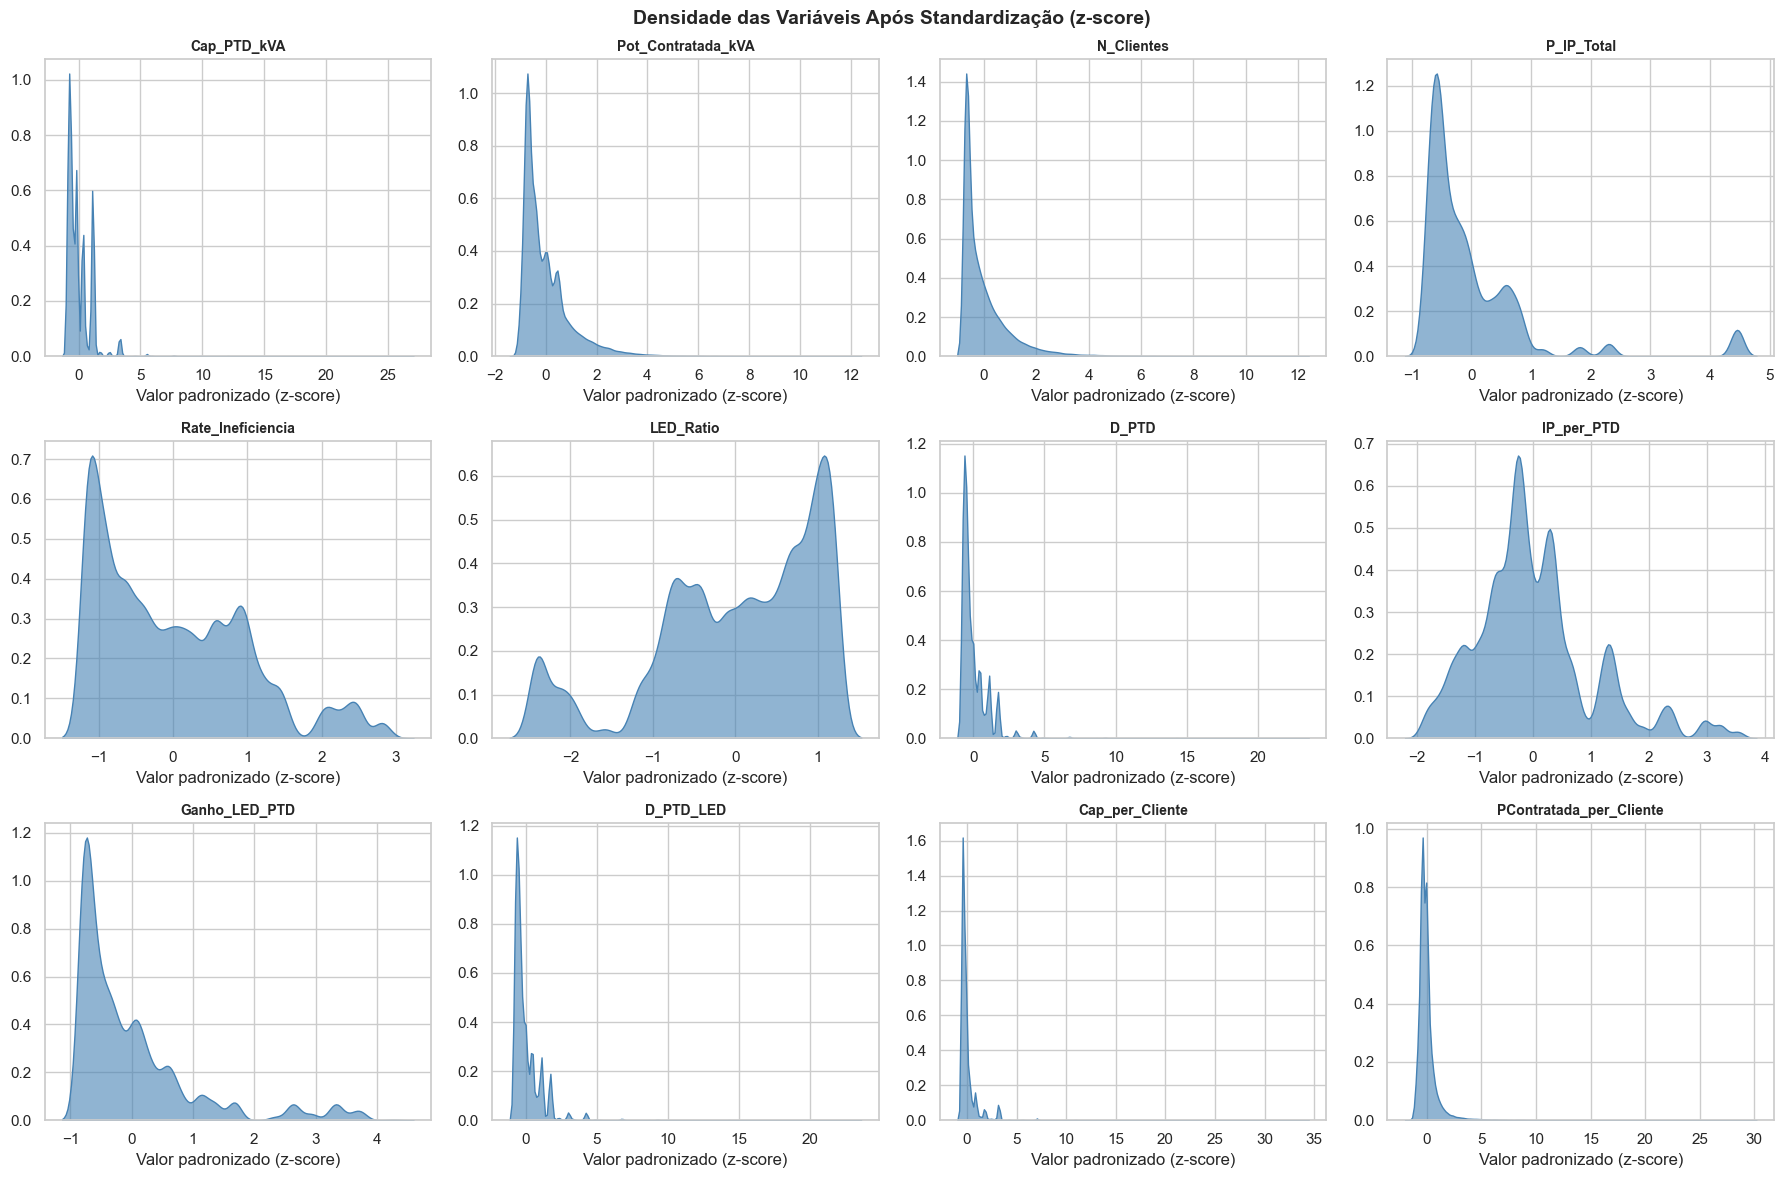

In [98]:
# Visualização final: distribuição das variáveis após standardização
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

cols_plot = [c for c in cols_numericas[:12]]
for i, col in enumerate(cols_plot):
    sns.kdeplot(df_scaled[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor padronizado (z-score)')
    axes[i].set_ylabel('')

for j in range(len(cols_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidade das Variáveis Após Standardização (z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()